# Binary Mask Classifier — compliant vs non_compliant

Collapses with_mask vs {without_mask, mask_weared_incorrect} into a 2-class problem. Reuses the same ResNet18 + oversampling approach validated in main.ipynb.

## 0. Setup

In [11]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from training import (
    CROPS_DIR, BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, VAL_SPLIT, SEED, CHECKPOINTS,
    get_device, build_dataloaders_binary, build_model, run_epoch,
)
from evaluation import evaluate_model_binary


## 1. Train

In [13]:
torch.manual_seed(SEED)

device = get_device()
print(f"Using device: {device}")

train_loader, val_loader, classes, train_targets, _ = build_dataloaders_binary(CROPS_DIR, BATCH_SIZE, VAL_SPLIT, SEED)
print(f"Classes: {classes}")

model = build_model(architecture='ResNet', num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
eval_criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)


Using device: mps
Classes: ['compliant', 'non_compliant']


In [14]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, eval_criterion, optimizer, device, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINTS['ResNet_binary'])
        print(f"  Saved new best model (val loss {val_loss:.4f})")

print(f"Training done. Best validation loss: {best_val_loss:.4f}")


Epoch 1/40 | train loss 0.1797 acc 0.9275 | val loss 0.0866 acc 0.9653
  Saved new best model (val loss 0.0866)
Epoch 2/40 | train loss 0.0879 acc 0.9681 | val loss 0.0612 acc 0.9723
  Saved new best model (val loss 0.0612)
Epoch 3/40 | train loss 0.0515 acc 0.9854 | val loss 0.0490 acc 0.9806
  Saved new best model (val loss 0.0490)
Epoch 4/40 | train loss 0.0656 acc 0.9768 | val loss 0.0819 acc 0.9653
Epoch 5/40 | train loss 0.0354 acc 0.9882 | val loss 0.0747 acc 0.9736
Epoch 6/40 | train loss 0.0683 acc 0.9774 | val loss 0.0596 acc 0.9764
Epoch 7/40 | train loss 0.0248 acc 0.9913 | val loss 0.0439 acc 0.9834
  Saved new best model (val loss 0.0439)
Epoch 8/40 | train loss 0.0447 acc 0.9851 | val loss 0.0450 acc 0.9820
Epoch 9/40 | train loss 0.0600 acc 0.9788 | val loss 0.0689 acc 0.9792
Epoch 10/40 | train loss 0.0349 acc 0.9924 | val loss 0.0577 acc 0.9750
Epoch 11/40 | train loss 0.0139 acc 0.9951 | val loss 0.0533 acc 0.9820
Epoch 12/40 | train loss 0.0164 acc 0.9941 | val loss

## 2. Training curves

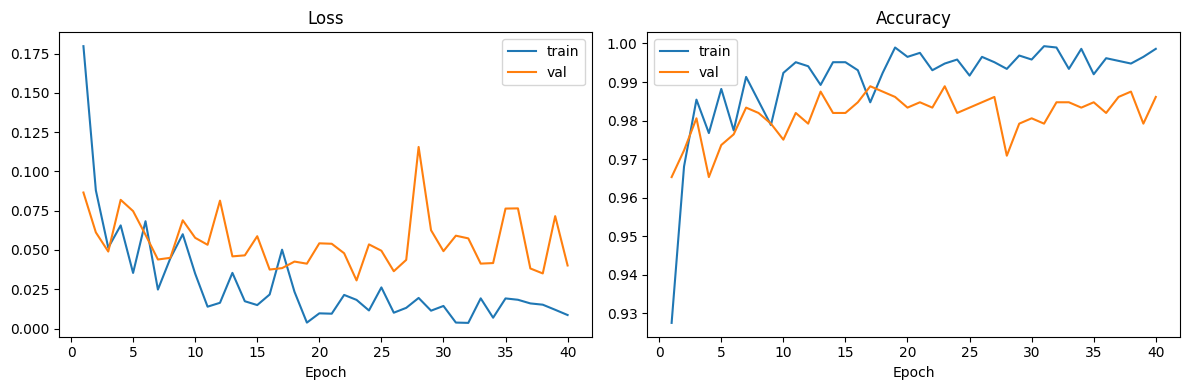

In [15]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## 3. Evaluate on validation set

In [18]:
results = evaluate_model_binary(checkpoint_path=CHECKPOINTS['ResNet_binary'], architecture='ResNet')
print(results["report"])


               precision    recall  f1-score   support

    compliant       0.99      0.99      0.99       576
non_compliant       0.97      0.97      0.97       145

     accuracy                           0.99       721
    macro avg       0.98      0.98      0.98       721
 weighted avg       0.99      0.99      0.99       721



## 4. Confusion matrix

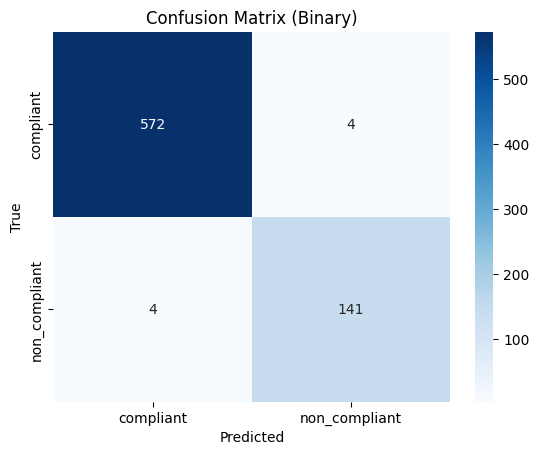

In [19]:
sns.heatmap(
    results["confusion_matrix"], annot=True, fmt="d",
    xticklabels=results["classes"], yticklabels=results["classes"], cmap="Blues",
)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Binary)")
plt.show()
